In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import re
import pandas as pd
import seaborn as sns

In [2]:
data_dir = "../output/"
runs = os.listdir(data_dir)
print(len(runs))

690


In [16]:
METRIC_PATTERNS = {
    "total_cycle": re.compile(r"total cycle =\s*(\d+)"),
    "load_cycle": re.compile(r"load cycle =\s*(\d+)"),
    "multiply_cycle": re.compile(r"multiply cycle =\s*(\d+)"),
    "merge_writeback_cycle": re.compile(r"merge and writeback cycle =\s*(\d+)"),
    "total_sram_cycle": re.compile(r"total SRAM cycle =\s*(\d+)"),
    "total_dram_cycle": re.compile(r"total DRAM cycle =\s*(\d+)"),
    "total_pe_cycle": re.compile(r"total PE cycle =\s*(\d+)"),
    "total_dram_access_a": re.compile(r"total DRAM access A =\s*(\d+)"),
    "total_dram_access_b": re.compile(r"total DRAM access B =\s*(\d+)"),
    "total_dram_access_c": re.compile(r"total DRAM access C =\s*(\d+)"),
    "hitrate": re.compile(r"hitrate =\s*([0-9eE+\-.]+)"),
}

config_fields = re.compile(r'CGust(\w+)_(\d+\.\d+)MB_(\d+\.\d+)GBs_(\d+)PEs_(\d+)sbanks__([\w.-]+)_(\d)_data_(\d)_coord_(\d)\.txt')
def parse_config_from_filename(filename):
    match = config_fields.match(filename)
    if not match:
        print(filename)
    mode, sram_mb, dram_bandwidth_gbs, pes, sram_banks, matrix_name, transpose, data_bytes, coord_bytes = match.groups()
    return pd.Series({
            'mode'               : mode
           ,'sram_mb'            : sram_mb
           ,'dram_bandwidth_gbs' : dram_bandwidth_gbs
           ,'pes'                : pes
           ,'sram_banks'         : sram_banks
           ,'transpose'          : True if transpose == '1' else False
           ,'data_bytes'         : data_bytes
           ,'coord_bytes'        : coord_bytes
           ,'matrix type'        : 'dense' if 'dense' in filename else 'sparse'
           ,'matrix'             : matrix_name[:len(matrix_name)//2 - 2]
           })

def parse_runs(filenames):
    rows = []
    bad_data = []
    for file in filenames:
        with open(data_dir + file, 'r') as f:
            text = f.read()
            columns = {key:METRIC_PATTERNS[key].findall(text) for key in METRIC_PATTERNS}

        
        min_len = min([len(columns[key]) for key in columns])
        if min_len == 0:
            bad_data.append(file)
            continue
        
        columns['file'] = [file] * min_len
        columns['testcase'] = ['CurrentCache', 'SeaCache', 'InnerSP', 'Sparch', 'X-cache', 'Scratchpad']

        
        data = pd.DataFrame.from_dict({key:columns[key][:min_len] for key in columns})
        rows.append(data)
    return pd.concat(rows), bad_data

In [17]:
df, bad_runs = parse_runs(runs)
print(len(bad_runs))
df.info()

186
<class 'pandas.DataFrame'>
Index: 3024 entries, 0 to 5
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   total_cycle            3024 non-null   str  
 1   load_cycle             3024 non-null   str  
 2   multiply_cycle         3024 non-null   str  
 3   merge_writeback_cycle  3024 non-null   str  
 4   total_sram_cycle       3024 non-null   str  
 5   total_dram_cycle       3024 non-null   str  
 6   total_pe_cycle         3024 non-null   str  
 7   total_dram_access_a    3024 non-null   str  
 8   total_dram_access_b    3024 non-null   str  
 9   total_dram_access_c    3024 non-null   str  
 10  hitrate                3024 non-null   str  
 11  file                   3024 non-null   str  
 12  testcase               3024 non-null   str  
dtypes: str(13)
memory usage: 330.8 KB


In [18]:
configs = df.file.apply(parse_config_from_filename)
data = pd.concat([df, configs], axis=1).reset_index(drop=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   total_cycle            3024 non-null   str  
 1   load_cycle             3024 non-null   str  
 2   multiply_cycle         3024 non-null   str  
 3   merge_writeback_cycle  3024 non-null   str  
 4   total_sram_cycle       3024 non-null   str  
 5   total_dram_cycle       3024 non-null   str  
 6   total_pe_cycle         3024 non-null   str  
 7   total_dram_access_a    3024 non-null   str  
 8   total_dram_access_b    3024 non-null   str  
 9   total_dram_access_c    3024 non-null   str  
 10  hitrate                3024 non-null   str  
 11  file                   3024 non-null   str  
 12  testcase               3024 non-null   str  
 13  mode                   3024 non-null   str  
 14  sram_mb                3024 non-null   str  
 15  dram_bandwidth_gbs     3024 non-null   str  
 16 

In [19]:
numeric_cols = [col for col in data.columns if 'file' not in col and 'testcase' not in col and 'mode' not in col and 'matrix' not in col]
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_cycle            3024 non-null   int64  
 1   load_cycle             3024 non-null   int64  
 2   multiply_cycle         3024 non-null   int64  
 3   merge_writeback_cycle  3024 non-null   int64  
 4   total_sram_cycle       3024 non-null   int64  
 5   total_dram_cycle       3024 non-null   int64  
 6   total_pe_cycle         3024 non-null   int64  
 7   total_dram_access_a    3024 non-null   int64  
 8   total_dram_access_b    3024 non-null   int64  
 9   total_dram_access_c    3024 non-null   int64  
 10  hitrate                2520 non-null   float64
 11  file                   3024 non-null   str    
 12  testcase               3024 non-null   str    
 13  mode                   3024 non-null   str    
 14  sram_mb                3024 non-null   float64
 15  dram_bandwidth_

In [20]:
data.to_csv('../output/parsed_data.csv')

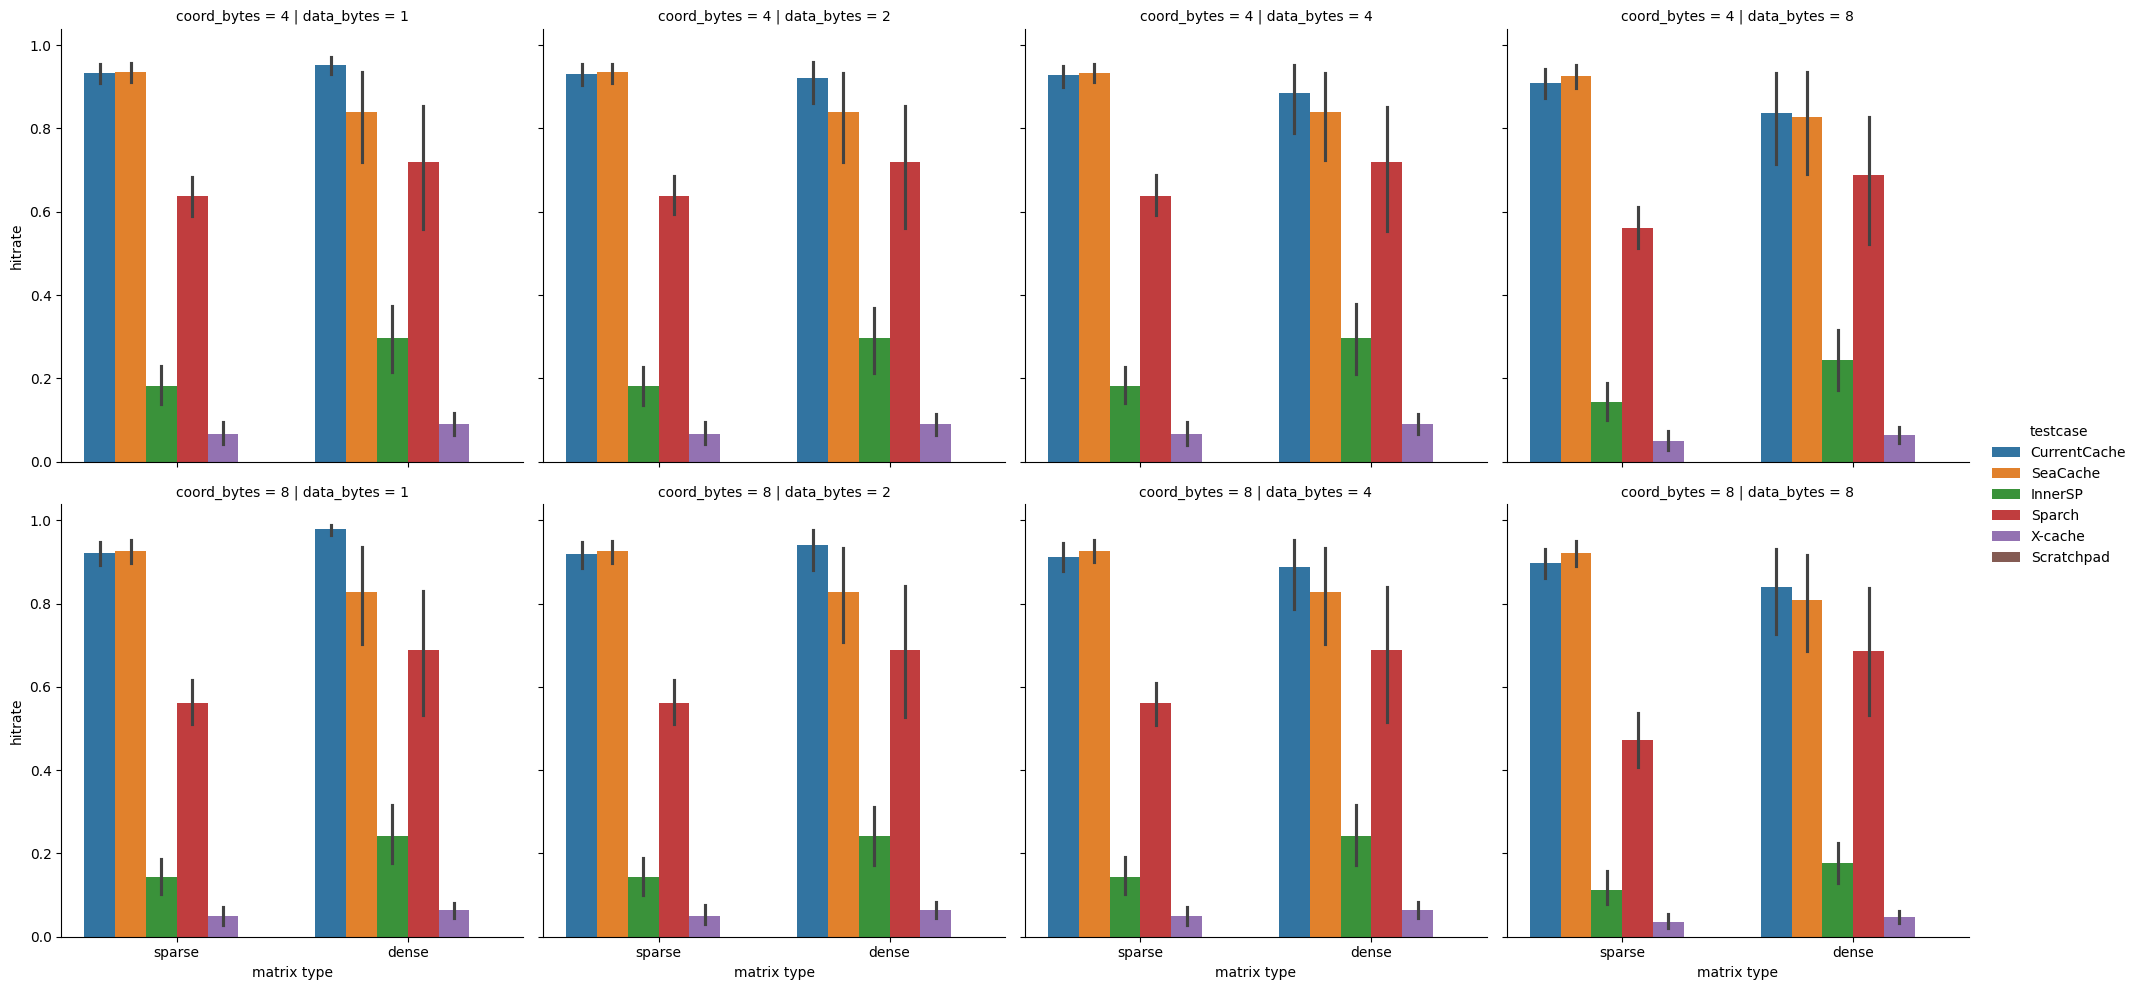

In [21]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='hitrate', hue='testcase', kind='bar', x='matrix type')
plt.savefig('../renderings/hitrate.png')

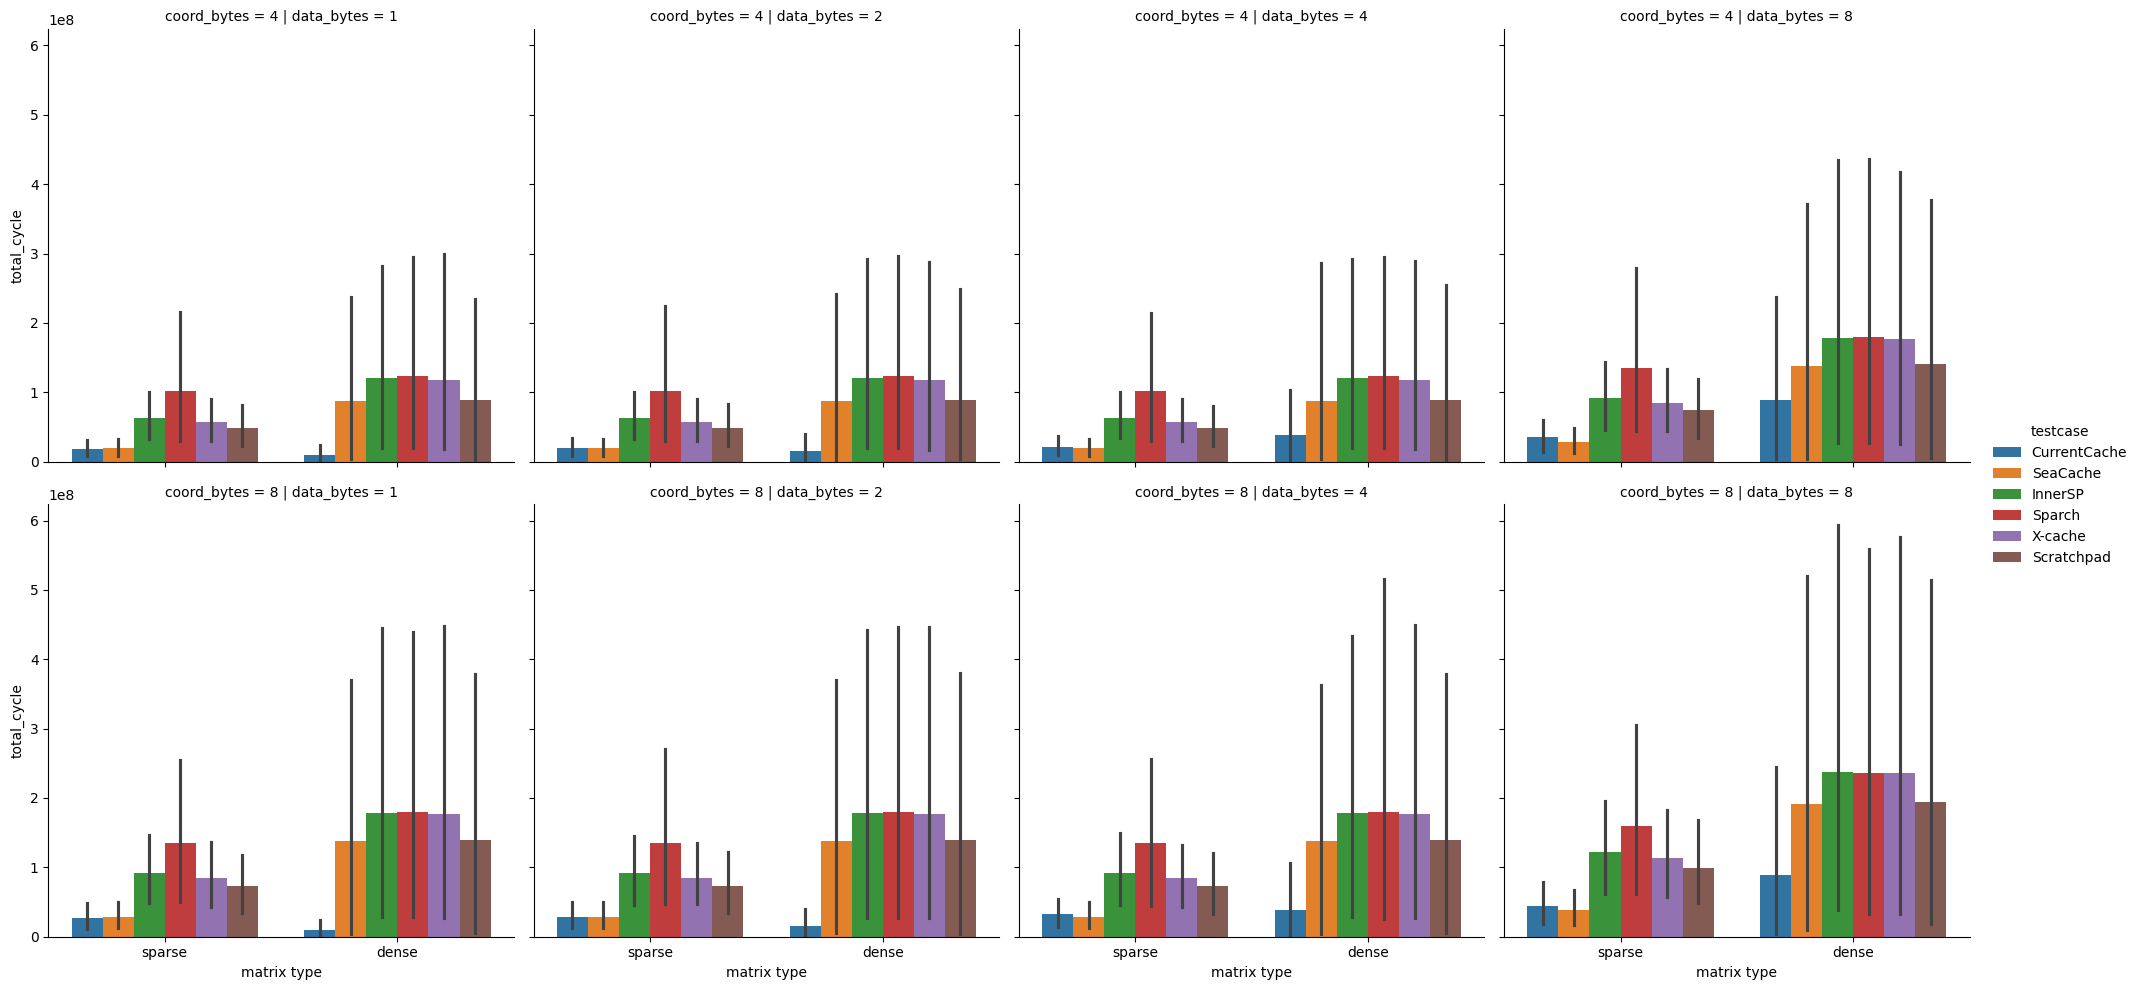

In [22]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='total_cycle', hue='testcase', kind='bar', x='matrix type')

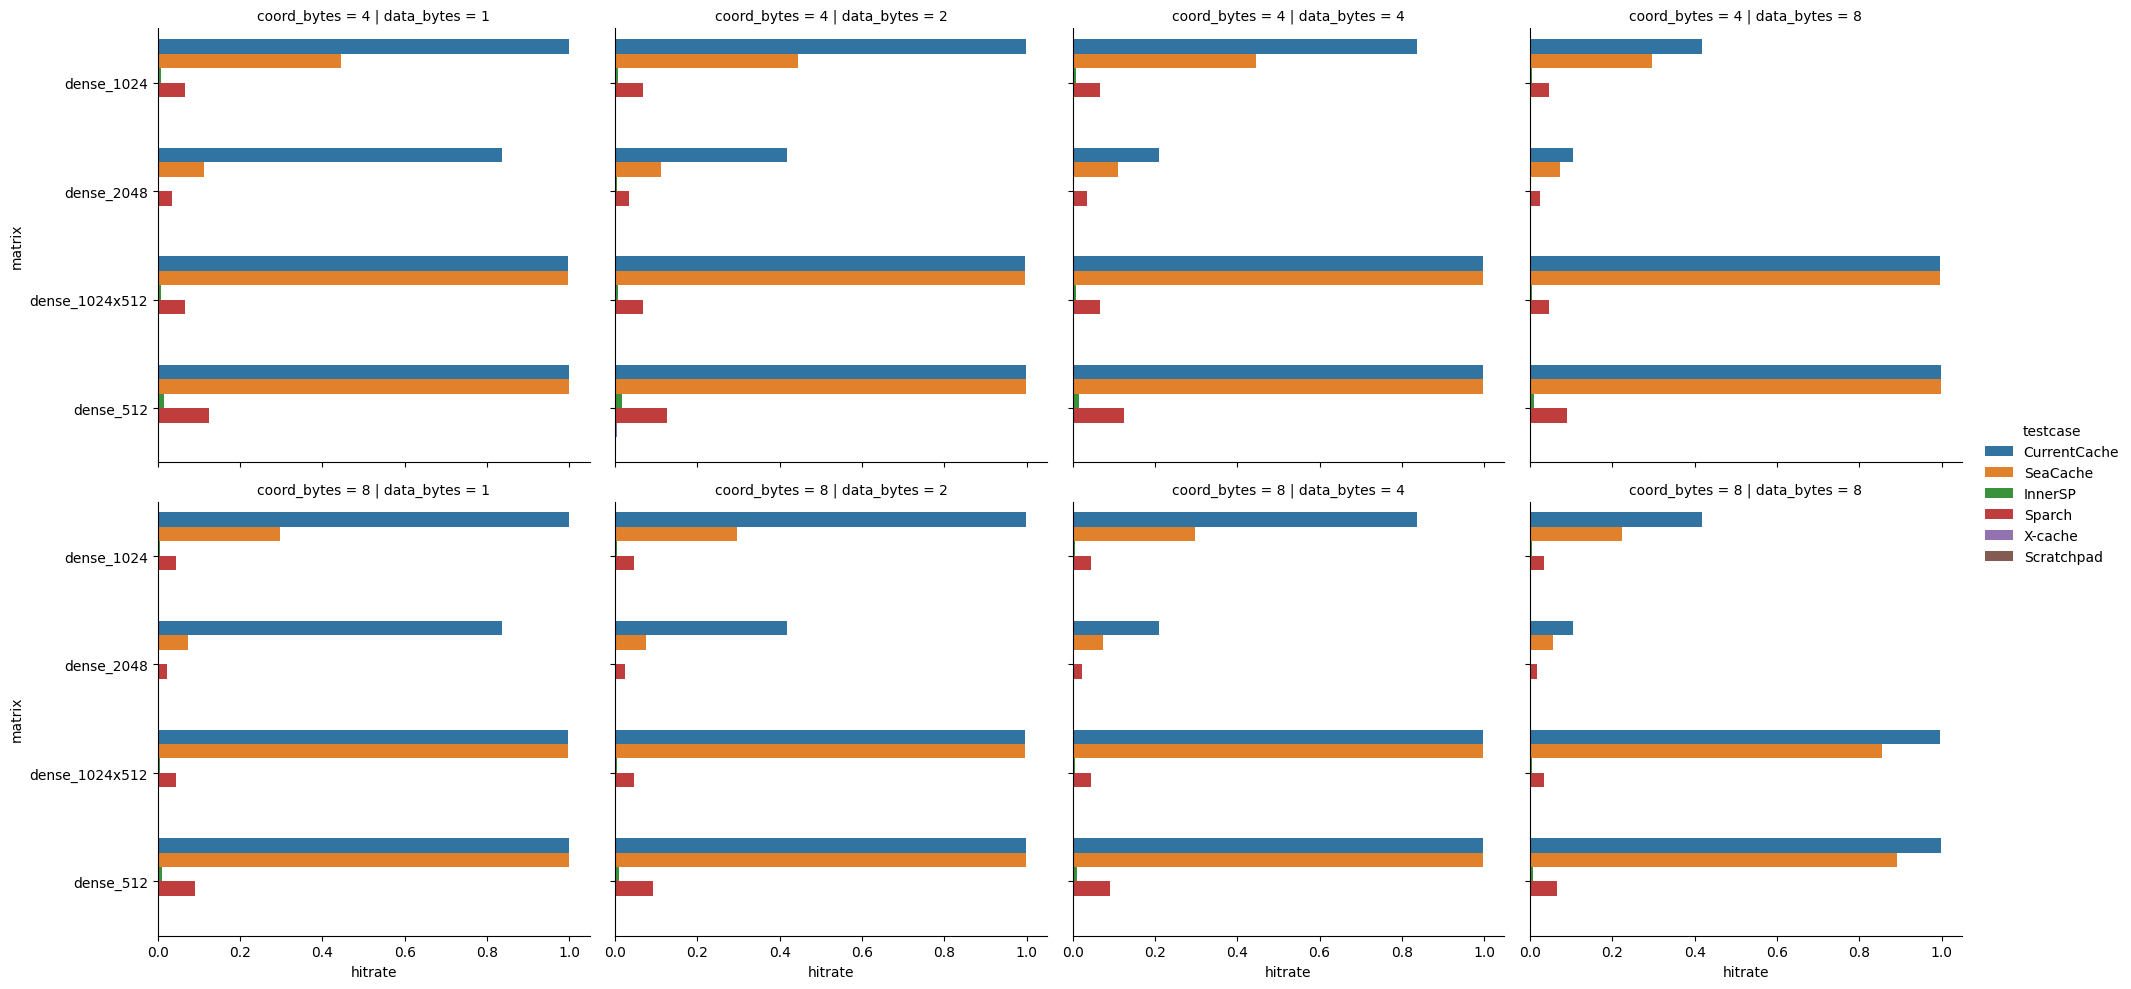

In [23]:
mask = data['matrix'].str.contains('dense_1024') | data['matrix'].str.contains('dense_512') | data['matrix'].str.contains('dense_2048')
sns.catplot(data=data.loc[mask], x='hitrate', y='matrix', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes')
plt.savefig('../renderings/dense_sweep.png')

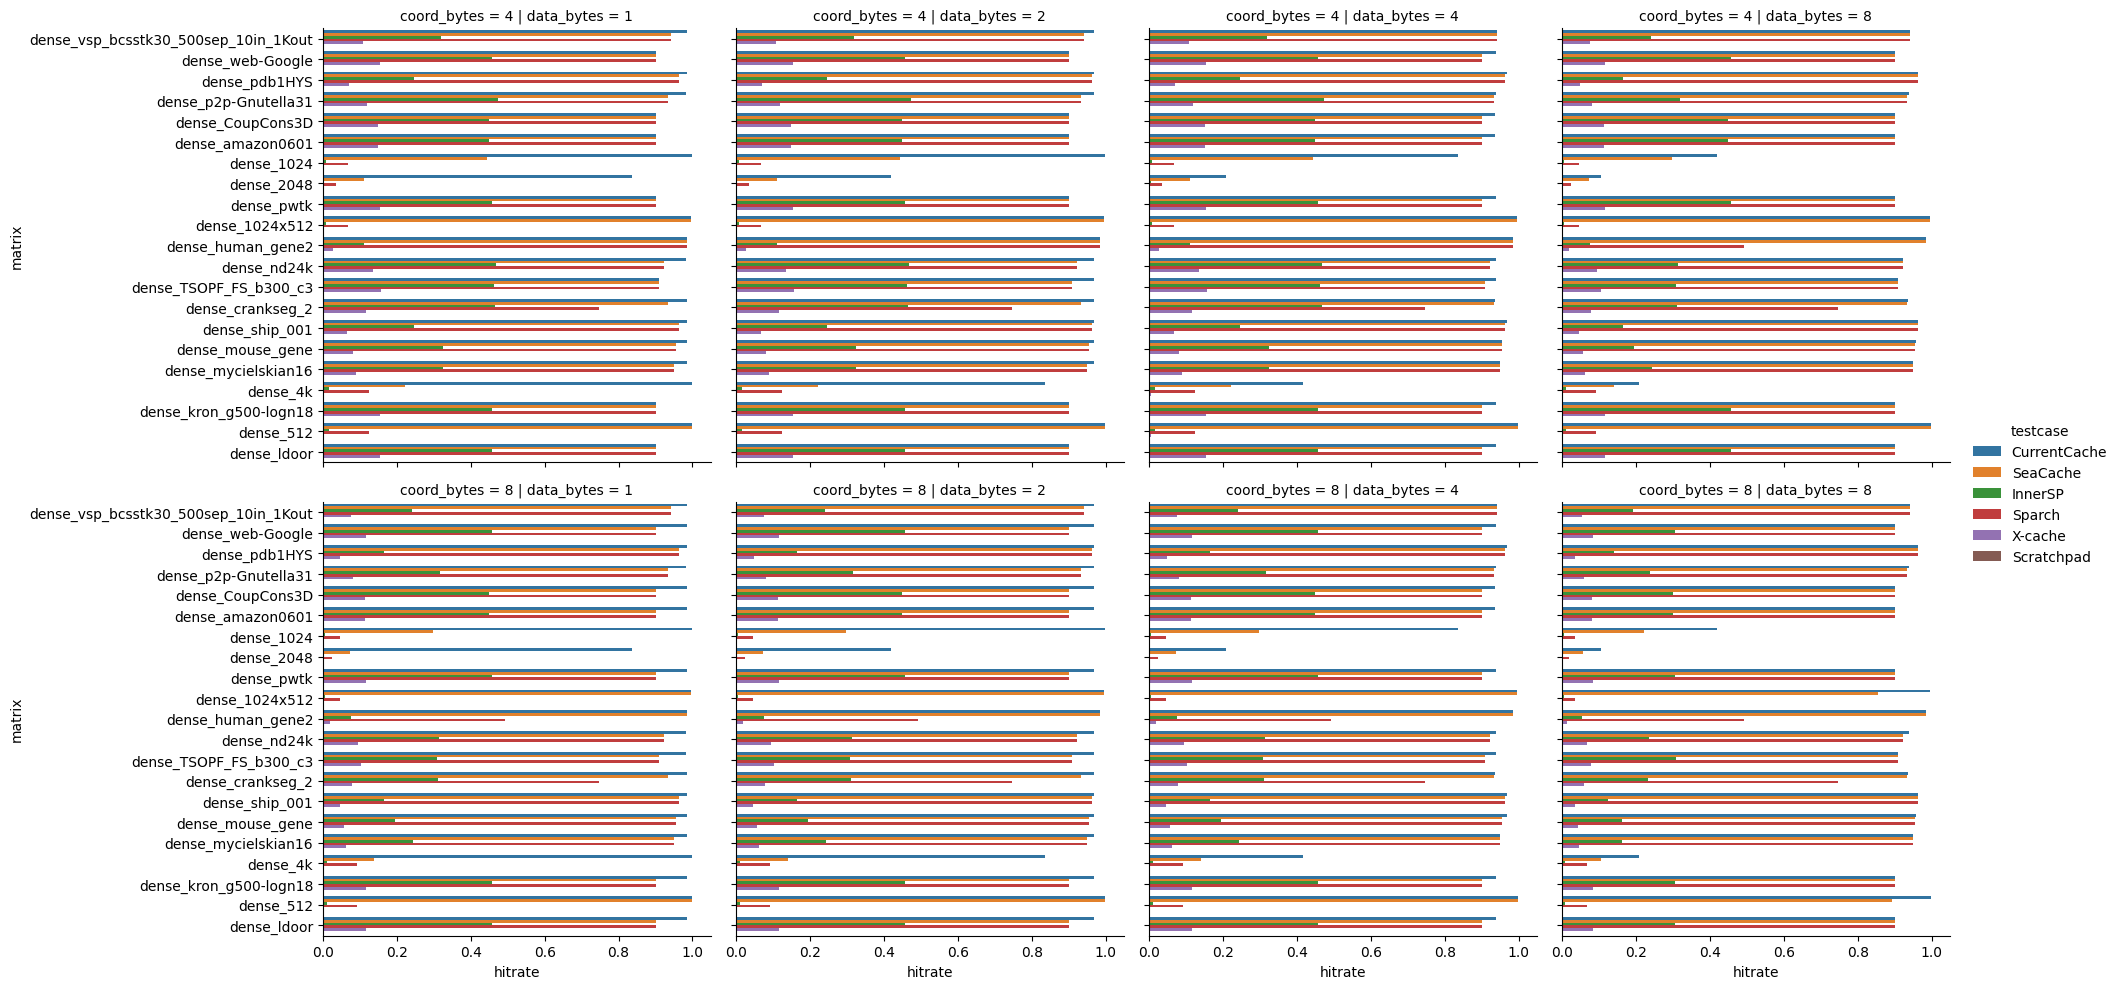

In [24]:
mask = data['matrix'].str.contains('dense')
sns.catplot(data=data.loc[mask], x='hitrate', y='matrix', hue='testcase', orient='h', aspect=1, height=5, kind='bar', row='coord_bytes', col='data_bytes')
plt.savefig('../renderings/full_dense_sweep.png')

In [25]:
data['normalized_cyc'] = 0.
mask = data.testcase == 'SeaCache'
compare_point = data.loc[mask].set_index('matrix').total_cycle
for testcase in data['testcase'].unique():
    mask = data.testcase == testcase
    tmp = data.loc[mask].set_index('matrix').total_cycle / compare_point
    data.loc[mask, 'normalized_cyc'] = tmp.values


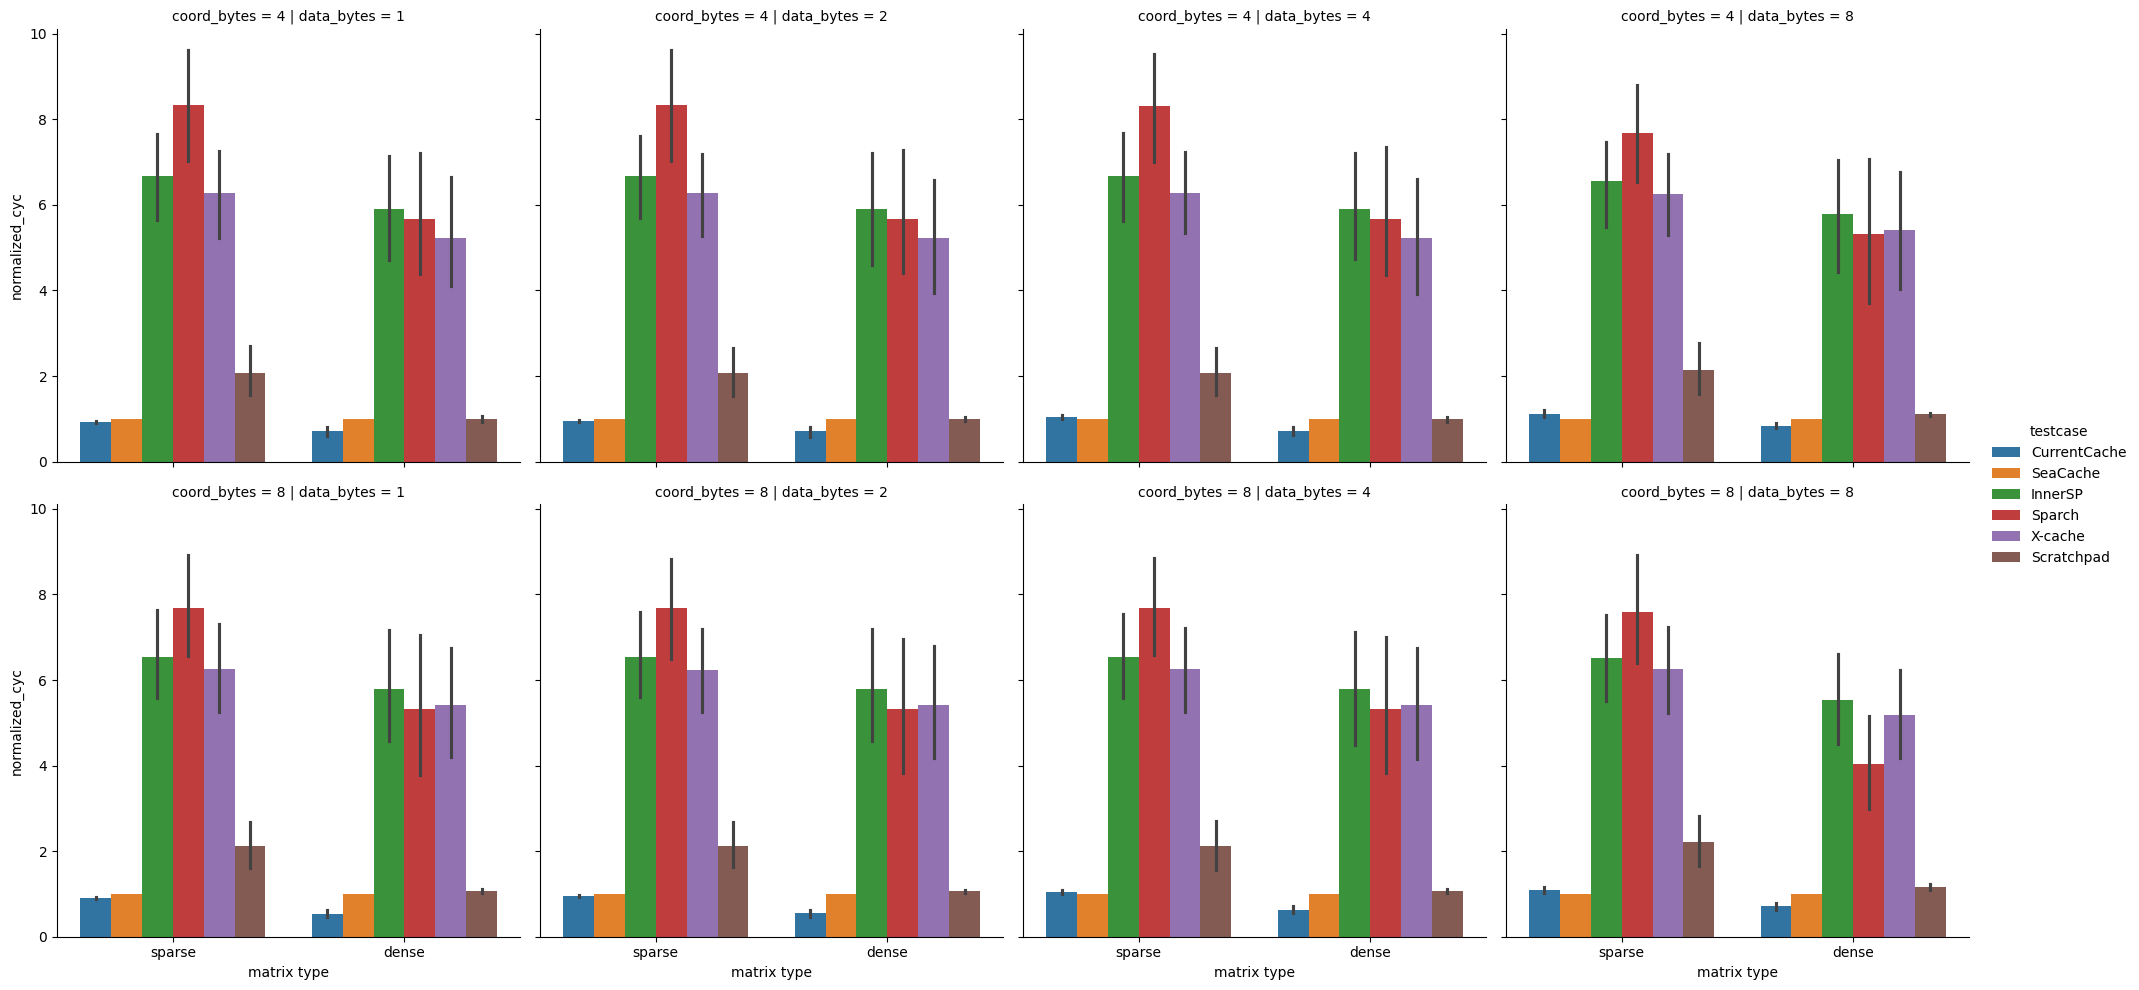

In [26]:
sns.catplot(data=data, col='data_bytes', row='coord_bytes', y='normalized_cyc', hue='testcase', kind='bar', x='matrix type')
plt.savefig('../renderings/relative_cycles.png')

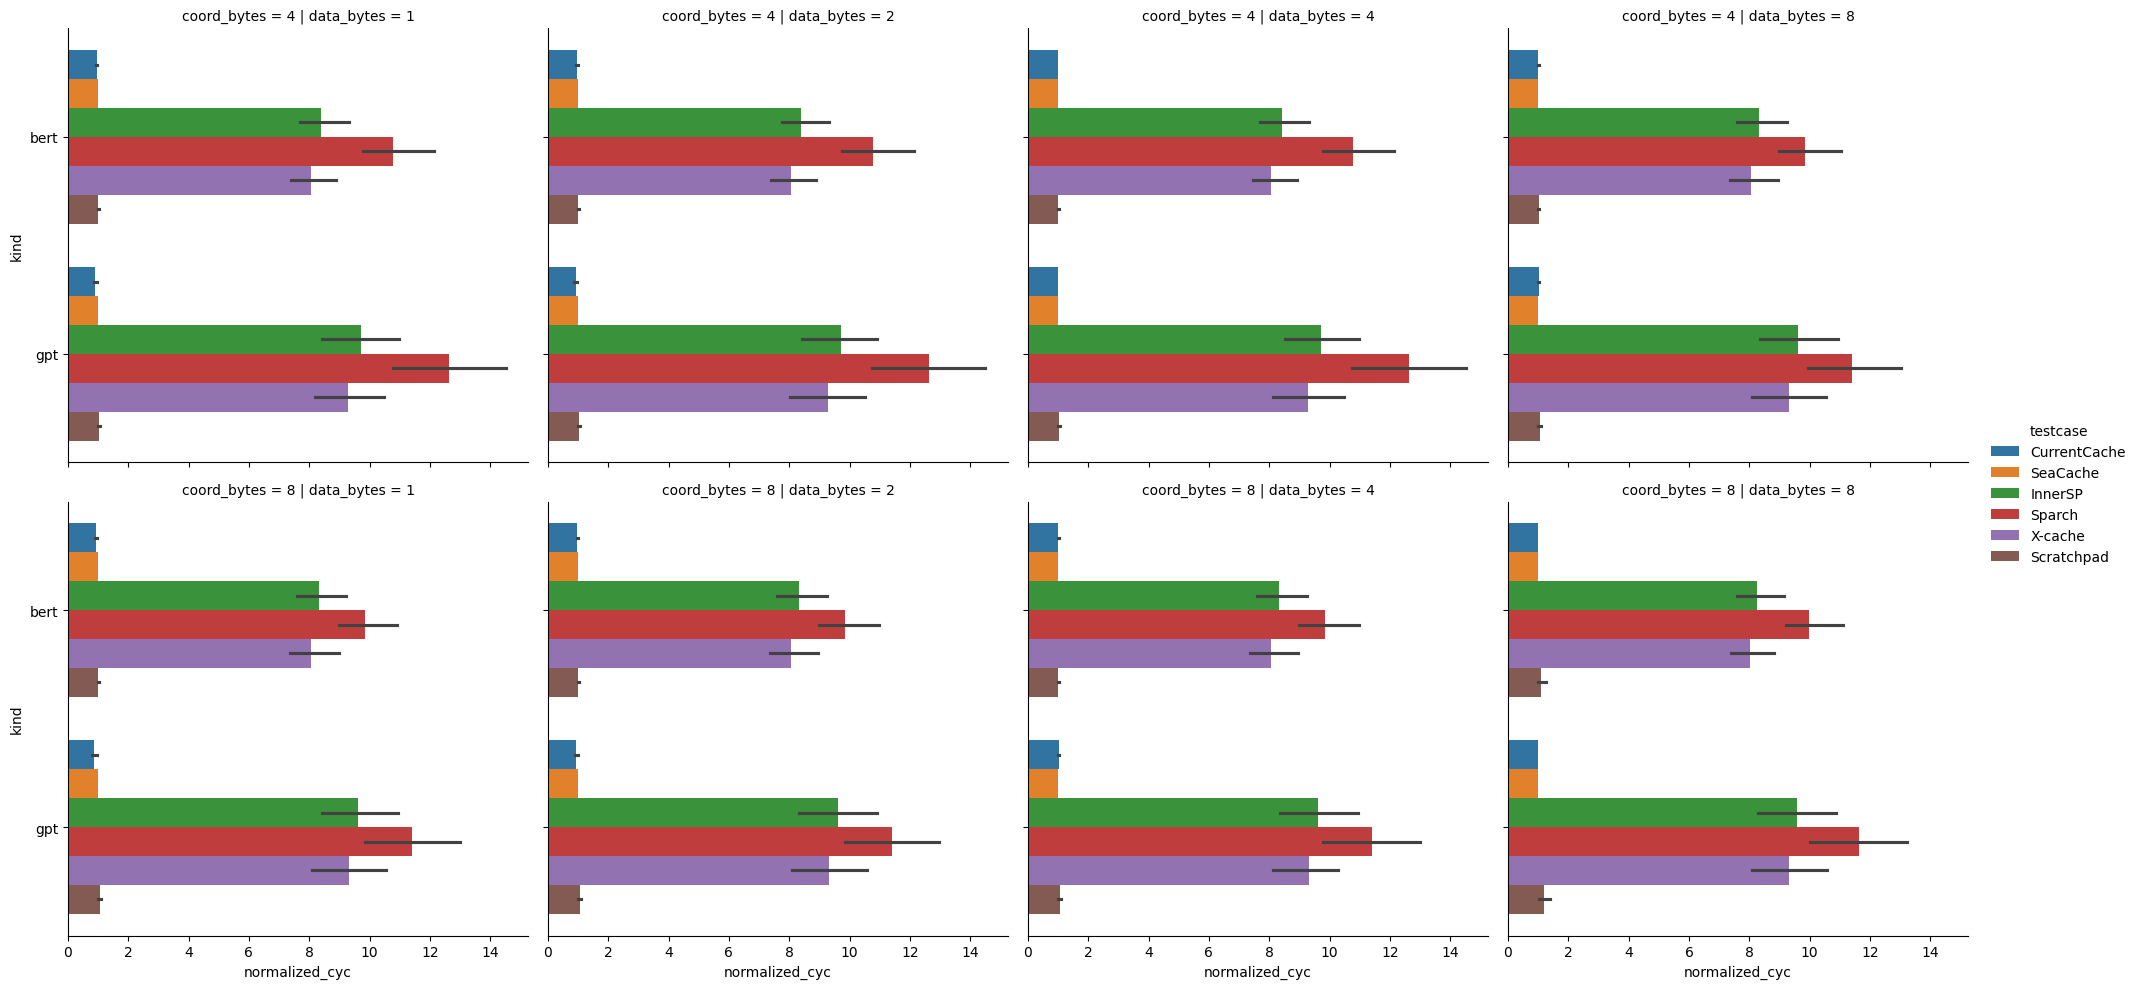

In [27]:
bert = data['matrix'].str.contains('bert')
gpt = data['matrix'].str.contains('gpt')
data['kind'] = 'general'
data.loc[bert, 'kind'] = 'bert'
data.loc[gpt, 'kind'] = 'gpt'
fig = sns.catplot(data=data.loc[bert | gpt], x='normalized_cyc', y='kind', hue='testcase', orient='h', aspect=1, kind='bar', row='coord_bytes', col='data_bytes')
plt.savefig('../renderings/llm_sweep.png')